In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)
df_DA_US = df[(df['job_title_short']=='Data Analyst') & (df['job_country'] == 'United States')].copy()

c:\Users\Ryan\anaconda3\envs\pyp\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


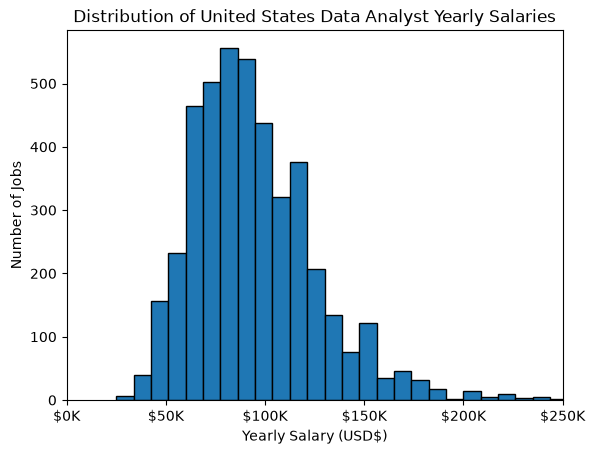

In [2]:
df_DA_US['salary_year_avg'].plot(kind='hist', bins=40, edgecolor='black')
plt.xlim(0,250000)
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.title('Distribution of United States Data Analyst Yearly Salaries')
plt.ylabel('Number of Jobs')
plt.xlabel('Yearly Salary (USD$)')
plt.show()

In [3]:
df_DA_US =df_DA_US.dropna(subset='salary_year_avg')
df_DA_US['salary_year_avg'].sample(10)

485263     52000.00
470954     64140.00
187430     82500.00
380268     51862.75
439335     67000.00
719519    137610.00
431291     75000.00
469037    140000.00
285352     50000.00
317827    111175.00
Name: salary_year_avg, dtype: float64

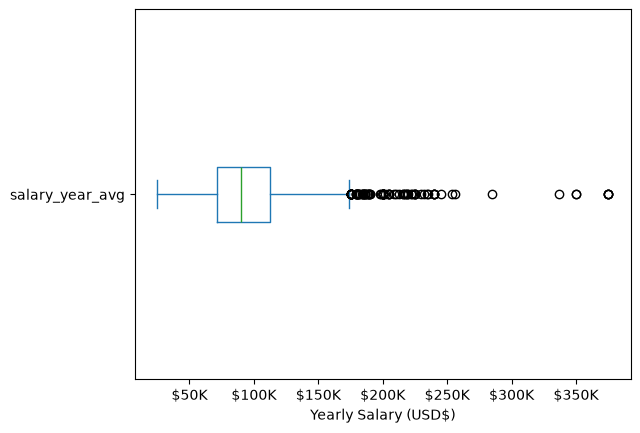

In [4]:
df_DA_US['salary_year_avg'].plot(kind='box', vert=False)
plt.xlabel('Yearly Salary (USD$)')
plt.ylabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))


In [5]:
# plt.boxplot(df_DA_US['salary_year_avg'], vert=False)

In [6]:
# job_titles(for labels and list comprehension) > df_US(for these jobs) and drop na > list comprehension > plot and cleaning

C:\Users\Ryan\AppData\Local\Temp\ipykernel_19256\900840323.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, tick_labels=job_titles, vert=False)


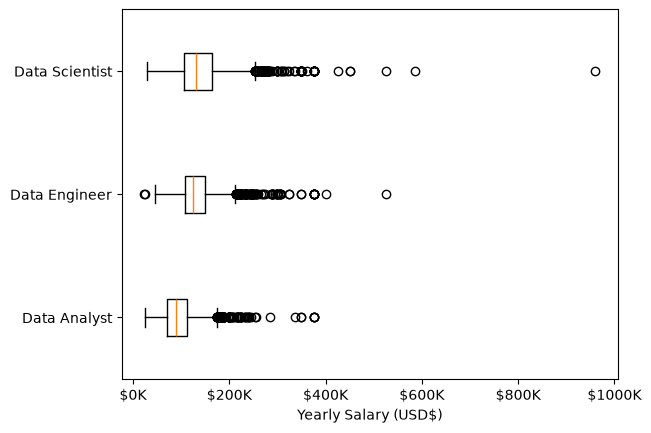

In [ ]:

#plt.boxplot(job_list, labels=job_titles, vert=False)
# job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
# df_US = df[(df['job_title_short'].isin(job_titles))&(df['job_country'] == 'United States')].copy()
# df_US = df_US.dropna(subset = 'salary_year_avg')
# job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]
# plt.boxplot(job_list, tick_labels=job_titles, vert=False)
# plt.title('')
# plt.xlabel('Yearly Salary (USD$)')
# ax = plt.gca()
# ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
# plt.show()


C:\Users\Ryan\AppData\Local\Temp\ipykernel_19256\3939084543.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, tick_labels=job_titles, vert=False)


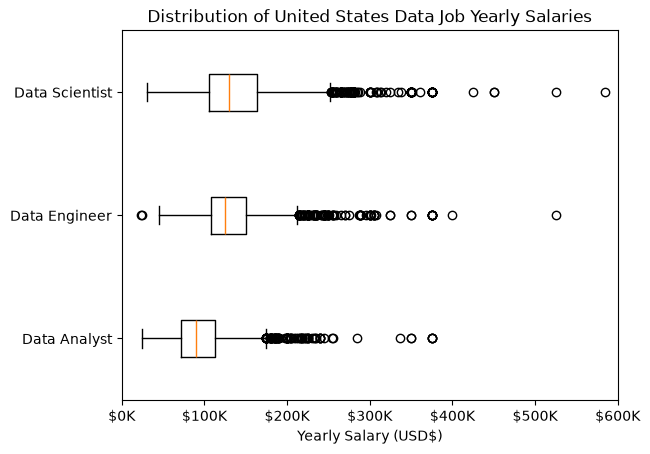

In [27]:
# plt.boxplot(job_list, labels=job_titles, vert=False)
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()
df_US.dropna(subset='salary_year_avg', inplace=True)
job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]
plt.boxplot(job_list, tick_labels=job_titles, vert=False)
plt.title('Distribution of United States Data Job Yearly Salaries')
plt.xlabel('Yearly Salary (USD$)')
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()

